# A unified RNA + protein + chromatin PBMC atlas from three assays

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ashford-A/UniVI/blob/main/docs/tutorials/experimental/pbmc_mosaic_atlas.ipynb)

> **Experimental.** This is a mosaic integration: no single dataset measures every pair of modalities
> the way the model uses them, and the three cohorts differ in chemistry, donors and cell preparation.
> The notebook therefore holds out ground truth and measures how well the integration works rather than
> assuming it does. Settings are starting values, not tuned ones.

Three PBMC datasets from `univi.datasets`, each measuring a different subset of modalities:

| cohort | assay | RNA | protein (ADT) | chromatin (ATAC) |
| --- | --- | --- | --- | --- |
| `hao_citeseq_pbmc` | CITE-seq | ✓ | ✓ (228 antibodies) | |
| `pbmc_multiome_10k` | 10x Multiome | ✓ | | ✓ (peaks) |
| `teaseq_pbmc` | TEA-seq | ✓ | ✓ (47 antibodies) | ✓ (500-bp tiles) |

One UniVI model gets one encoder and one decoder per modality and is trained on all cohorts at once:
every batch comes from one cohort and uses the modalities that cohort measured. RNA, present
everywhere, ties the space together. The notebook:

1. harmonizes features: shared genes, a matched antibody panel, and TEA-seq tiles projected onto the
   Multiome peak set;
2. holds out one TEA-seq well as trimodal ground truth;
3. trains a **full mosaic** model (all three cohorts) and a **bridge-only** model (CITE-seq + Multiome,
   never seeing TEA-seq), and asks whether the bridge-only model can predict protein from chromatin,
   a pair of modalities it never saw measured together;
4. builds a joint atlas, checks how well cohorts mix, and transfers the Hao et al. annotation to the
   Multiome and TEA-seq cells;
5. predicts surface protein for the Multiome cells, which were never stained.

**Compute.** About 1.4 GB of downloads. Loading the full CITE-seq RNA matrix needs several GB of RAM
(it is subsampled right after loading); a Colab GPU runtime with the standard RAM allocation is enough.

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install -q "univi[tutorials]>=1.1" "pandas==2.2.3"

In [2]:
import gc
import re

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import torch
from IPython.display import display
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

import univi
import univi.datasets as uds
from univi import ModalityConfig, TrainingConfig, UniVIConfig, UniVIMultiModalVAE, UniVITrainer
from univi.evaluation import (compute_foscttm, compute_modality_mixing, cross_modal_predict, decode_from_latent,
                              encode_adata, label_transfer_knn, pearson_corr_per_feature)
from univi.preprocessing import ADTPreprocessor, ATACPreprocessor, RNAPreprocessor, split_by_label
from univi.utils.seed import set_seed
from univi.workflows import make_loader, save_reference, stack_embeddings

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
set_seed(0)
dense = lambda x: x.toarray() if sp.issparse(x) else np.asarray(x)
print(f"UniVI {univi.__version__} on {device}")

UniVI 1.1.0 on cuda


C:\Users\ashfo\micromamba\envs\univi-release-050\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
N_EPOCHS = 300
BATCH_SIZE = 256
N_HVG = 2000                 # HVGs per reference cohort; the union is used
N_LSI = 101                  # LSI components fit before dropping the first
N_CITE_CELLS = 30000         # CITE-seq training cells (subsampled from the published training pool)
N_CITE_TEST = 5000           # CITE-seq held-out cells used for evaluation
TEA_HOLDOUT = "GSM5123953_X066-MP0C1W5_leukopak_perm-cells_tea"   # well 5, as in the paper
CITE_LABEL = "celltype.l2"   # annotation transferred to the other cohorts
PER_COHORT_SCALING = True    # z-score each modality within each cohort (see Section 2)
TRAIN_BRIDGE_ONLY = True     # also train the model that never sees TEA-seq
ADT_ALIASES = {}             # manual matches, {"TEA-seq antibody name": "CITE-seq antibody name"}

## 1. Load and split the three cohorts

- **CITE-seq**: the file's `obs["split"]` (the paper's split) supplies training and test pools, which are
  subsampled to `N_CITE_CELLS` and `N_CITE_TEST` cells.
- **Multiome**: stratified 80/10/10 split by cell type.
- **TEA-seq**: well 5 is held out completely; the other wells are split 90/10 for training and
  validation.

In [4]:
rng = np.random.default_rng(0)


def pick(mask, n):
    idx = np.flatnonzero(mask)
    return np.sort(rng.choice(idx, size=min(n, len(idx)), replace=False))


cite = uds.hao_citeseq_pbmc()
if "split" in cite["rna"].obs and {"train", "test"} <= set(cite["rna"].obs["split"].astype(str)):
    split = cite["rna"].obs["split"].astype(str).to_numpy()
    tr_pool, va_pool, te_pool = split == "train", split == "val", split == "test"
else:                                            # files without a stored split: make one
    u = rng.random(cite["rna"].n_obs)
    tr_pool, va_pool, te_pool = u < 0.8, (u >= 0.8) & (u < 0.9), u >= 0.9
cite_idx = {"train": pick(tr_pool, N_CITE_CELLS), "val": pick(va_pool, max(2, N_CITE_CELLS // 8)),
            "test": pick(te_pool, N_CITE_TEST)}
keep = np.concatenate(list(cite_idx.values()))
cite = {k: v[keep].copy() for k, v in cite.items()}      # drop the rest of the 161k cells from memory
offset = np.cumsum([0] + [len(v) for v in cite_idx.values()])
cite_idx = {k: np.arange(offset[i], offset[i + 1]) for i, k in enumerate(cite_idx)}
_ = gc.collect()

mult = uds.pbmc_multiome_10k()
mult_idx = split_by_label(mult["rna"].obs["cell_type"], train_fraction=0.8, val_fraction=0.1, seed=0)

tea = uds.load("teaseq_pbmc")
well = tea["rna"].obs["sample_id"].astype(str).to_numpy()
assert TEA_HOLDOUT in set(well), f"held-out well not found; wells: {sorted(set(well))}"
rest = rng.permutation(np.flatnonzero(well != TEA_HOLDOUT))
tea_idx = {"train": np.sort(rest[len(rest) // 10:]), "val": np.sort(rest[: len(rest) // 10]),
           "test": np.flatnonzero(well == TEA_HOLDOUT)}

pd.DataFrame({name: {k: len(v) for k, v in idx.items()}
              for name, idx in {"CITE-seq": cite_idx, "Multiome": mult_idx, "TEA-seq": tea_idx}.items()})

,CITE-seq,Multiome,TEA-seq
train,30000,7698,20226
val,3750,956,2247
test,5000,977,7421


## 2. Harmonize the features

### RNA: shared genes

Genes present in all three files; HVGs are selected separately in the two reference cohorts
(CITE-seq and Multiome training cells) and their union is used, so that neither chemistry dominates
the selection. TEA-seq is not used for feature selection.

In [5]:
shared_genes = cite["rna"].var_names.intersection(mult["rna"].var_names).intersection(tea["rna"].var_names)
print(f"shared genes: {len(shared_genes):,} (CITE {cite['rna'].n_vars:,}, Multiome {mult['rna'].n_vars:,}, "
      f"TEA {tea['rna'].n_vars:,})")
hvg_sets = [RNAPreprocessor(n_hvg=N_HVG).fit(d["rna"][idx["train"]][:, shared_genes]).features_
            for d, idx in [(cite, cite_idx), (mult, mult_idx)]]
genes = list(dict.fromkeys(hvg_sets[0] + hvg_sets[1]))
print(f"HVG union: {len(genes):,} genes ({len(set(hvg_sets[0]) & set(hvg_sets[1])):,} selected in both)")

shared genes: 19,657 (CITE 20,729, Multiome 29,095, TEA 36,601)
HVG union: 3,165 genes (835 selected in both)


### Protein: a matched antibody panel

Antibody names differ between panels (clone suffixes such as `-1`/`-2`, punctuation, case). Names are
matched after removing a trailing `-<digit>` clone suffix, upper-casing, and dropping punctuation;
where one marker has several clones in CITE-seq, the clone with the highest mean count in training cells
is used. **Check the printed table** and add missed or wrong matches to `ADT_ALIASES`; automatic
matching by name cannot know, for example, that two different names describe the same antigen.

In [6]:
def norm_marker(name):
    return re.sub(r"[^0-9A-Z]", "", re.sub(r"-\d$", "", str(name)).upper())


cite_counts = sp.csr_matrix(cite["adt"][cite_idx["train"]].layers["counts"])
cite_mean = pd.Series(np.asarray(cite_counts.mean(axis=0)).ravel(), index=cite["adt"].var_names)
by_key = {}
for name in cite["adt"].var_names:
    k = norm_marker(name)
    if k not in by_key or cite_mean[name] > cite_mean[by_key[k]]:
        by_key[k] = name
panel = {}
for tea_name in tea["adt"].var_names:
    if tea_name in ADT_ALIASES:
        panel[tea_name] = ADT_ALIASES[tea_name]
    elif norm_marker(tea_name) in by_key:
        panel[tea_name] = by_key[norm_marker(tea_name)]
panel_df = pd.DataFrame({"TEA-seq": list(panel), "CITE-seq": list(panel.values())})
print(f"matched {len(panel)} of {tea['adt'].n_vars} TEA-seq antibodies")
print("unmatched TEA-seq antibodies:", sorted(set(tea["adt"].var_names) - set(panel)))
panel_df

matched 37 of 47 TEA-seq antibodies
unmatched TEA-seq antibodies: ['CD10', 'CD197', 'FceRI', 'IgG1-K-Isotype-Control', 'KLRG1', 'TCR-Va24-Ja18', 'TCR-Va7.2', 'TCR-a/b', 'TCR-g/d', 'total']


,TEA-seq,CITE-seq
0,CD11b,CD11b-1
1,CD11c,CD11c
2,CD123,CD123
3,CD127,CD127
4,CD14,CD14
5,CD141,CD141
6,CD16,CD16
7,CD172a,CD172a
8,CD185,CD185
9,CD19,CD19


The matched antibodies are renamed to the TEA-seq names in both cohorts, so the ADT modality has one
feature space.

In [7]:
def adt_panel(adata, names, new_names):
    out = adata[:, list(names)].copy()
    out.var_names = pd.Index(list(new_names))
    return out


adt_names = list(panel)
cite_adt = adt_panel(cite["adt"], panel.values(), adt_names)
tea_adt = adt_panel(tea["adt"], adt_names, adt_names)

### Chromatin: TEA-seq tiles projected onto Multiome peaks

Multiome ATAC is a peak matrix; TEA-seq ATAC is a matrix of 500-bp genome tiles (kept if open in
0.5–80% of training-well cells). Each TEA-seq cell's counts in all tiles overlapping a Multiome peak are
summed into that peak, which puts both cohorts in the Multiome peak space. The TF-IDF/LSI transform is
then fit on Multiome training cells only. Peaks that overlap no retained tile receive no TEA-seq signal;
the fraction is printed.

In [8]:
def coords(adata):
    v = adata.var
    for cols in (("chrom", "chromStart", "chromEnd"), ("chrom", "start", "end")):
        if set(cols) <= set(v.columns):
            return pd.DataFrame({"chrom": v[cols[0]].astype(str).to_numpy(), "start": v[cols[1]].astype(np.int64).to_numpy(),
                                 "end": v[cols[2]].astype(np.int64).to_numpy()}, index=adata.var_names)
    parts = adata.var_names.to_series().str.extract(r"^(.+?)[:\-_](\d+)[\-_](\d+)$")
    if parts.isna().any().any():
        raise ValueError("Could not parse coordinates from var_names.")
    return pd.DataFrame({"chrom": parts[0].to_numpy(), "start": parts[1].astype(np.int64).to_numpy(),
                         "end": parts[2].astype(np.int64).to_numpy()}, index=adata.var_names)


def overlap_matrix(tiles, peaks):
    """Sparse (n_tiles x n_peaks) indicator of intervals that overlap by at least 1 bp."""
    rows, cols = [], []
    for chrom, pk in peaks.groupby("chrom"):
        tl = tiles[tiles["chrom"] == chrom]
        if tl.empty:
            continue
        order = np.argsort(pk["start"].to_numpy(), kind="stable")
        p_start, p_end = pk["start"].to_numpy()[order], pk["end"].to_numpy()[order]
        p_col = peaks.index.get_indexer(pk.index[order])
        longest = int((p_end - p_start).max())
        t_start, t_end = tl["start"].to_numpy(), tl["end"].to_numpy()
        lo = np.searchsorted(p_start, t_start - longest, side="left")      # no earlier peak can reach the tile
        hi = np.searchsorted(p_start, t_end, side="left")                  # peaks starting before the tile ends
        n = np.maximum(hi - lo, 0)
        cand = np.repeat(lo, n) + (np.arange(n.sum()) - np.repeat(np.cumsum(n) - n, n))
        t_row = np.repeat(tiles.index.get_indexer(tl.index), n)
        hit = p_end[cand] > np.repeat(t_start, n)                          # candidate really overlaps
        rows.append(t_row[hit])
        cols.append(p_col[cand[hit]])
    rows = np.concatenate(rows) if rows else np.array([], dtype=int)
    cols = np.concatenate(cols) if cols else np.array([], dtype=int)
    return sp.csr_matrix((np.ones(len(rows), dtype=np.float32), (rows, cols)), shape=(len(tiles), len(peaks)))


peaks, tiles = coords(mult["atac"]), coords(tea["atac"])
assert set(peaks["chrom"]) & set(tiles["chrom"]), "Peak and tile chromosome names do not match."
M = overlap_matrix(tiles, peaks)
tea_counts = sp.csr_matrix(tea["atac"].layers["counts"], dtype=np.float32)
tea_atac = ad.AnnData(obs=tea["atac"].obs.copy(), var=mult["atac"].var.copy())
tea_atac.layers["counts"] = sp.csr_matrix(tea_counts @ M)
tea_atac.X = tea_atac.layers["counts"]
covered = np.asarray(M.sum(axis=0)).ravel() > 0
print(f"{int(M.nnz):,} tile-peak overlaps; {covered.mean():.1%} of {len(peaks):,} Multiome peaks overlap a "
      f"TEA-seq tile; median TEA-seq counts per cell in peak space: "
      f"{np.median(np.asarray(tea_atac.layers['counts'].sum(axis=1)).ravel()):.0f}")
del tea_counts
_ = gc.collect()

152,933 tile-peak overlaps; 49.4% of 107,194 Multiome peaks overlap a TEA-seq tile; median TEA-seq counts per cell in peak space: 5927


### Transforms, and why they are fit per cohort

The same cell type measured by different chemistries has different average expression, protein
counts and accessibility, and UniVI has no batch covariate. With `PER_COHORT_SCALING = True`, each
modality is z-scored **within each cohort** (on that cohort's training cells), which removes
per-feature offsets and scale differences between cohorts. It also removes genuine differences in
cell-type composition between cohorts from the feature means, which is acceptable here because all
three are PBMC samples. With `False`, every cohort is transformed with statistics fit on the reference
cohorts. TEA-seq transforms are always fit on its training wells only; the held-out well is only
transformed.

In [9]:
def fit_lsi_scaler(z):
    return StandardScaler().fit(z.X)


def scaled(adata_lsi, scaler):
    out = adata_lsi.copy()
    out.X = scaler.transform(out.X).astype(np.float32)
    return out


atac_prep = ATACPreprocessor(n_components=N_LSI, drop_first=True, scale=False).fit(mult["atac"][mult_idx["train"]])
rna_ref = RNAPreprocessor(n_hvg=None, scale=True).fit(
    ad.concat([cite["rna"][cite_idx["train"]][:, genes], mult["rna"][mult_idx["train"]][:, genes]],
              index_unique="-"))
adt_ref = ADTPreprocessor(scale=True).fit(cite_adt[cite_idx["train"]])
lsi_ref = fit_lsi_scaler(atac_prep.transform(mult["atac"][mult_idx["train"]]))

preps = {}
for name, d, idx, adt, atac_counts in [("cite", cite, cite_idx, cite_adt, None),
                                       ("mult", mult, mult_idx, None, mult["atac"]),
                                       ("tea", tea, tea_idx, tea_adt, tea_atac)]:
    train_rna = d["rna"][idx["train"]][:, genes]
    preps[name] = {
        "rna": RNAPreprocessor(n_hvg=None, scale=True).fit(train_rna) if PER_COHORT_SCALING else rna_ref,
        "adt": None if adt is None else (ADTPreprocessor(scale=True).fit(adt[idx["train"]])
                                         if PER_COHORT_SCALING else adt_ref),
        "lsi": None if atac_counts is None else (fit_lsi_scaler(atac_prep.transform(atac_counts[idx["train"]]))
                                                 if PER_COHORT_SCALING else lsi_ref),
    }


def cohort_parts(name, d, idx, adt, atac_counts):
    p = preps[name]
    out = {}
    for split_name, i in idx.items():
        mods = {"rna": p["rna"].transform(d["rna"][i])}
        if adt is not None:
            mods["adt"] = p["adt"].transform(adt[i])
        if atac_counts is not None:
            mods["atac"] = scaled(atac_prep.transform(atac_counts[i]), p["lsi"])
        out[split_name] = mods
    return out


data = {"CITE-seq": cohort_parts("cite", cite, cite_idx, cite_adt, None),
        "Multiome": cohort_parts("mult", mult, mult_idx, None, mult["atac"]),
        "TEA-seq": cohort_parts("tea", tea, tea_idx, tea_adt, tea_atac)}
for cohort, parts in data.items():
    print(cohort, {m: a.shape for m, a in parts["train"].items()})

CITE-seq {'rna': (30000, 3165), 'adt': (30000, 37)}
Multiome {'rna': (7698, 3165), 'atac': (7698, 100)}
TEA-seq {'rna': (20226, 3165), 'adt': (20226, 37), 'atac': (20226, 100)}


## 3. Mosaic training

`make_loader` builds one loader per cohort (its cells are paired across the modalities it measured).
A small wrapper interleaves their batches in random order each epoch; `UniVITrainer` only iterates
over the loader, so it trains on the mixture without changes. For a batch from a cohort, the loss uses
the modalities that cohort measured: its self- and cross-reconstructions and the alignment between
its posteriors.

In [10]:
class MosaicLoader:
    """Interleave batches of several per-cohort loaders; every batch comes from a single cohort."""

    def __init__(self, loaders, seed=0):
        self.loaders, self.seed, self.epoch = dict(loaders), seed, 0

    def __len__(self):
        return sum(len(loader) for loader in self.loaders.values())

    def __iter__(self):
        order = np.concatenate([[name] * len(loader) for name, loader in self.loaders.items()])
        np.random.default_rng(self.seed + self.epoch).shuffle(order)
        self.epoch += 1
        iterators = {name: iter(loader) for name, loader in self.loaders.items()}
        for name in order:
            yield next(iterators[name])


def build_model():
    n = {m: a.n_vars for m, a in data["TEA-seq"]["train"].items()}
    cfg = UniVIConfig(
        latent_dim=30, beta=1.25, gamma=4.35, encoder_dropout=0.10, decoder_dropout=0.05,
        kl_anneal_start=50, kl_anneal_end=85, align_anneal_start=75, align_anneal_end=110,
        modalities=[ModalityConfig("rna", n["rna"], [512, 256, 128], [128, 256, 512]),
                    ModalityConfig("adt", n["adt"], [128, 64], [64, 128], recon_weight=2.0),
                    ModalityConfig("atac", n["atac"], [128, 64], [64, 128])])
    return UniVIMultiModalVAE(cfg, loss_mode="v1", v1_recon="avg", normalize_v1_terms=True)


def train_mosaic(cohorts):
    set_seed(0)
    model = build_model()
    tr = MosaicLoader({c: make_loader(data[c]["train"], batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
                       for c in cohorts})
    va = MosaicLoader({c: make_loader(data[c]["val"], batch_size=1024) for c in cohorts})
    trainer = UniVITrainer(model, tr, va, TrainingConfig(
        n_epochs=N_EPOCHS, batch_size=BATCH_SIZE, lr=1e-3, weight_decay=1e-4, device=device, early_stopping=True,
        patience=50, best_epoch_warmup=110, log_every=50, grad_clip=5.0))
    history = trainer.fit()
    print(f"{' + '.join(cohorts)}: best epoch {trainer.best_epoch}")
    return model, history


models = {"full mosaic": train_mosaic(["CITE-seq", "Multiome", "TEA-seq"])[0]}
if TRAIN_BRIDGE_ONLY:
    models["bridge-only"] = train_mosaic(["CITE-seq", "Multiome"])[0]

[2026-09-22 15:14:43,192] [UniVITrainer] [INFO] TrainingConfig:
[2026-09-22 15:14:43,194] [UniVITrainer] [INFO]   n_epochs: 300
[2026-09-22 15:14:43,195] [UniVITrainer] [INFO]   batch_size: 256
[2026-09-22 15:14:43,195] [UniVITrainer] [INFO]   lr: 0.001
[2026-09-22 15:14:43,196] [UniVITrainer] [INFO]   weight_decay: 0.0001
[2026-09-22 15:14:43,196] [UniVITrainer] [INFO]   device: 'cuda'
[2026-09-22 15:14:43,197] [UniVITrainer] [INFO]   log_every: 50
[2026-09-22 15:14:43,198] [UniVITrainer] [INFO]   grad_clip: 5.0
[2026-09-22 15:14:43,198] [UniVITrainer] [INFO]   num_workers: 0
[2026-09-22 15:14:43,199] [UniVITrainer] [INFO]   seed: 0
[2026-09-22 15:14:43,199] [UniVITrainer] [INFO]   early_stopping: True
[2026-09-22 15:14:43,200] [UniVITrainer] [INFO]   patience: 50
[2026-09-22 15:14:43,200] [UniVITrainer] [INFO]   min_delta: 0.0
[2026-09-22 15:14:43,201] [UniVITrainer] [INFO]   best_epoch_warmup: 110
Training UniVI:   0%|          | 0/300 [00:00<?, ?it/s][2026-09-22 15:14:52,082] [UniV

CITE-seq + Multiome + TEA-seq: best epoch 253


Training UniVI:   0%|          | 0/300 [00:00<?, ?it/s][2026-09-22 15:56:44,598] [UniVITrainer] [INFO] [Epoch 001] Train loss=1521.3918 (beta=0.000, gamma=0.000)
[2026-09-22 15:56:44,763] [UniVITrainer] [INFO] [Epoch 001] Val loss=90097.9496 (beta=1.250, gamma=4.350)
Training UniVI:  16%|█▋        | 49/300 [03:00<15:11,  3.63s/it, beta=0.000, gamma=0.000, train_loss=1346.5494, val_loss=969127.0000][2026-09-22 15:59:45,084] [UniVITrainer] [INFO] [Epoch 050] Train loss=1346.5738 (beta=0.000, gamma=0.000)
[2026-09-22 15:59:45,258] [UniVITrainer] [INFO] [Epoch 050] Val loss=957977.0875 (beta=1.250, gamma=4.350)
Training UniVI:  33%|███▎      | 99/300 [06:04<12:18,  3.67s/it, beta=1.250, gamma=2.983, train_loss=1393.5724, val_loss=1399.6382][2026-09-22 16:02:49,463] [UniVITrainer] [INFO] [Epoch 100] Train loss=1393.6463 (beta=1.250, gamma=3.107)
[2026-09-22 16:02:49,629] [UniVITrainer] [INFO] [Epoch 100] Val loss=1400.5330 (beta=1.250, gamma=4.350)
Training UniVI:  50%|████▉     | 149/300 [

CITE-seq + Multiome: best epoch 182


## 4. Ground truth: the held-out TEA-seq well

Well 5 was not used for training either model, and the bridge-only model never saw any TEA-seq cell.
All three modalities were measured in these cells, so we can check:

- **alignment**: FOSCTTM between each pair of modality embeddings of the same cells;
- **protein prediction**: per-antibody Pearson r between measured protein and protein predicted from
  RNA alone and from ATAC alone.

In the bridge-only model, protein and chromatin were never measured in the same training cells, so
ATAC → protein prediction has to go through the latent space that RNA shares with both. As a point of
reference, a supervised linear model (ridge regression) is fit on TEA-seq training wells to predict
protein directly from the same inputs; it uses TEA-seq pairing that the bridge-only model never had.

In [11]:
held = data["TEA-seq"]["test"]
obs_adt = dense(held["adt"].X)
rows, per_protein = {}, {}
for name, model in models.items():
    z = {m: encode_adata(model, a, modality=m, device=device, latent="modality_mean") for m, a in held.items()}
    row = {f"FOSCTTM {a}-{b}": compute_foscttm(z[a], z[b]) for a, b in [("rna", "adt"), ("rna", "atac"), ("adt", "atac")]}
    for src in ("rna", "atac"):
        pred = cross_modal_predict(model, held[src], src_mod=src, tgt_mod="adt", device=device)
        r = pd.Series(pearson_corr_per_feature(obs_adt, pred), index=held["adt"].var_names)
        per_protein[(name, src)] = r
        row[f"{src}→protein median r"] = r.median()
    rows[name] = row

tea_train = data["TEA-seq"]["train"]
for src in ("rna", "atac"):
    ridge = Ridge(alpha=10.0).fit(dense(tea_train[src].X), dense(tea_train["adt"].X))   # alpha not tuned
    r = pd.Series(pearson_corr_per_feature(obs_adt, ridge.predict(dense(held[src].X))), index=held["adt"].var_names)
    per_protein[("ridge (TEA-seq supervised)", src)] = r
    rows.setdefault("ridge (TEA-seq supervised)", {})[f"{src}→protein median r"] = r.median()
pd.DataFrame(rows).T.round(3)

,FOSCTTM rna-adt,FOSCTTM rna-atac,FOSCTTM adt-atac,rna→protein median r,atac→protein median r
full mosaic,0.092,0.070,0.093,0.681,0.696
bridge-only,0.197,0.152,0.208,0.573,0.586
ridge (TEA-seq supervised),NaN,NaN,NaN,0.615,0.679


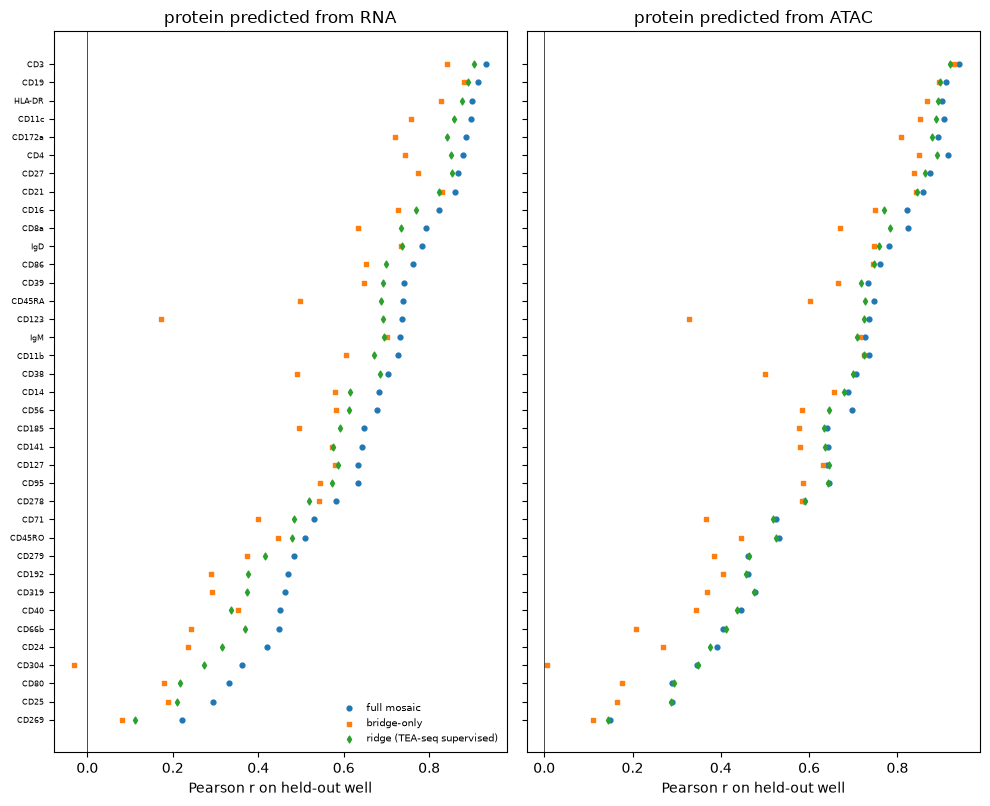

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 0.18 * len(adt_names) + 1.5), sharey=True)
order = per_protein[("full mosaic", "rna")].sort_values().index
for ax, src in zip(axes, ("rna", "atac")):
    for i, (name, _) in enumerate([k for k in per_protein if k[1] == src]):
        ax.scatter(per_protein[(name, src)].loc[order], np.arange(len(order)), s=12, label=name,
                   marker="osd"[i % 3])
    ax.set_yticks(range(len(order)), order, fontsize=6)
    ax.axvline(0, c="k", lw=0.5)
    ax.set(xlabel="Pearson r on held-out well", title=f"protein predicted from {src.upper()}")
axes[0].legend(frameon=False, fontsize=7)
plt.tight_layout()
plt.show()

If the bridge-only model's ATAC → protein correlations approach the full model's, RNA is an effective
bridge between chromatin and protein for these markers; proteins where it falls far short are
candidates for which chromatin carries information that RNA does not transmit (or where the
CITE-seq and TEA-seq antibody panels disagree).

## 5. The joint atlas

We embed held-out cells of all three cohorts. Each cohort is encoded from its RNA (the modality they
share), which makes cohorts comparable; `stack_embeddings` stacks them into one AnnData.

In [13]:
model = models["full mosaic"]
test_sets = [(c, "rna", data[c]["test"]["rna"]) for c in data]
atlas = stack_embeddings(model, test_sets, device=device)
cite_labels = cite["rna"].obs[CITE_LABEL].astype(str)
atlas.obs["cohort"] = atlas.obs["cohort"].astype(str)
sc.pp.neighbors(atlas, use_rep="X_univi", n_neighbors=30)
sc.tl.umap(atlas, random_state=0)

mix = compute_modality_mixing(atlas.obsm["X_univi"], atlas.obs["cohort"].to_numpy(), k=30)
p = atlas.obs["cohort"].value_counts(normalize=True)
print(f"fraction of 30 nearest neighbors from another cohort: {mix:.3f} "
      f"(a perfectly mixed atlas with these cohort sizes would give about {1 - (p ** 2).sum():.3f})")

fraction of 30 nearest neighbors from another cohort: 0.056 (a perfectly mixed atlas with these cohort sizes would give about 0.549)


### Transfer the Hao et al. annotation

CITE-seq cells carry the Hao et al. `celltype.l2` annotation. A k-NN classifier on the RNA embeddings of
CITE-seq training cells labels the Multiome and TEA-seq held-out cells. For Multiome cells, the
transferred labels can be compared with the file's own `cell_type` annotation (a label transfer from the
same Hao reference, done with Seurat): the heatmap shows, for each original label, which transferred
labels its cells receive.

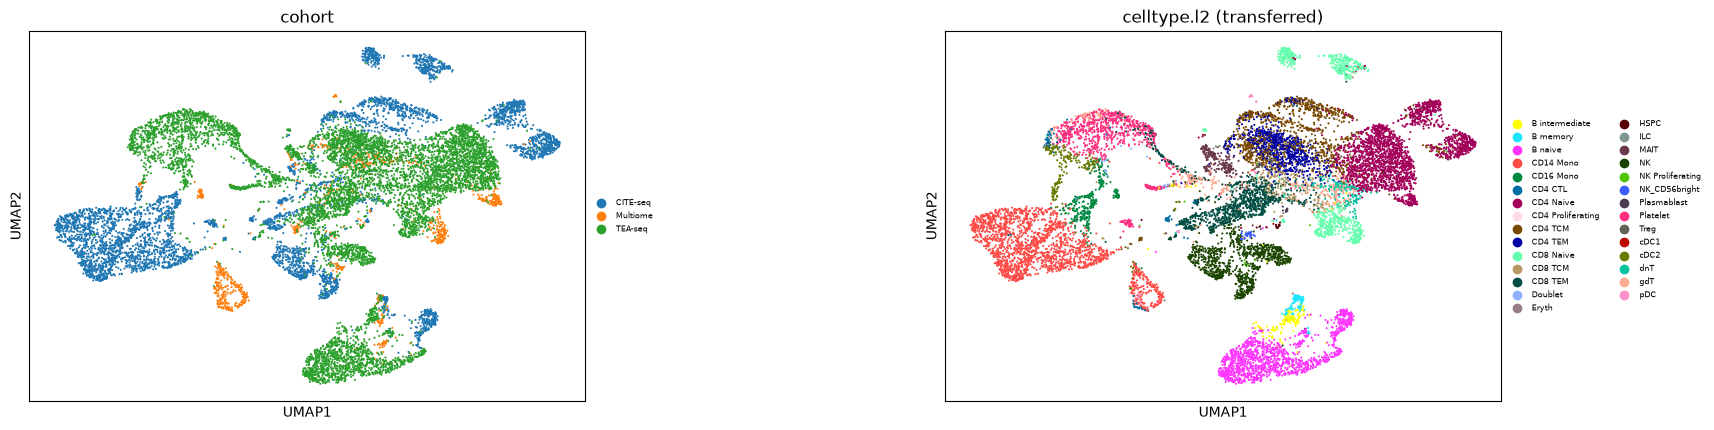

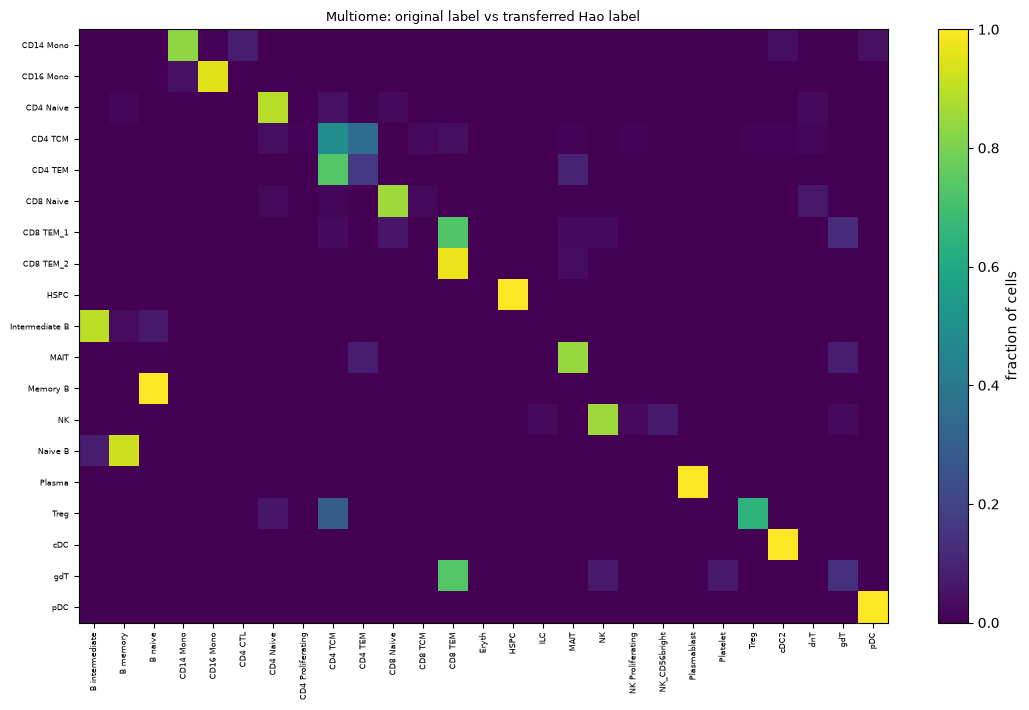

In [14]:
z_ref = encode_adata(model, data["CITE-seq"]["train"]["rna"], modality="rna", device=device, latent="modality_mean")
y_ref = cite_labels.iloc[cite_idx["train"]].to_numpy()
transferred = pd.Series(index=atlas.obs_names, dtype=object)
for c in data:
    sel = (atlas.obs["cohort"] == c).to_numpy()
    if c == "CITE-seq":
        transferred[sel] = cite_labels.iloc[cite_idx["test"]].to_numpy()
    else:
        pred, _, _ = label_transfer_knn(z_ref, y_ref, atlas.obsm["X_univi"][sel], k=15)
        transferred[sel] = pred
atlas.obs[f"{CITE_LABEL} (transferred)"] = pd.Categorical(transferred.astype(str))
sc.pl.umap(atlas, color=["cohort", f"{CITE_LABEL} (transferred)"], wspace=0.5, legend_fontsize=6)

sel = (atlas.obs["cohort"] == "Multiome").to_numpy()
orig = mult["rna"].obs["cell_type"].astype(str).iloc[mult_idx["test"]].to_numpy()
ct = pd.crosstab(pd.Series(orig, name="Multiome cell_type"),
                 pd.Series(atlas.obs[f"{CITE_LABEL} (transferred)"].to_numpy()[sel], name="transferred"),
                 normalize="index")
fig, ax = plt.subplots(figsize=(0.3 * ct.shape[1] + 3, 0.3 * ct.shape[0] + 1.5))
im = ax.imshow(ct.to_numpy(), cmap="viridis", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(ct.shape[1]), ct.columns, rotation=90, fontsize=6)
ax.set_yticks(range(ct.shape[0]), ct.index, fontsize=6)
plt.colorbar(im, ax=ax, label="fraction of cells")
ax.set_title("Multiome: original label vs transferred Hao label", fontsize=9)
plt.tight_layout()
plt.show()

## 6. Virtual CITE-seq for the Multiome cells

The Multiome cells were never stained with antibodies, but the model has a protein decoder. Encoding
each Multiome cell from **both** its RNA and ATAC (precision-weighted fusion) and decoding protein
gives a predicted surface phenotype. The values are in the ADT model space (per-cohort z-scored CLR),
so compare them across cell types rather than reading them as absolute abundance. Section 4 shows how
accurate such predictions were on cells where protein was measured.

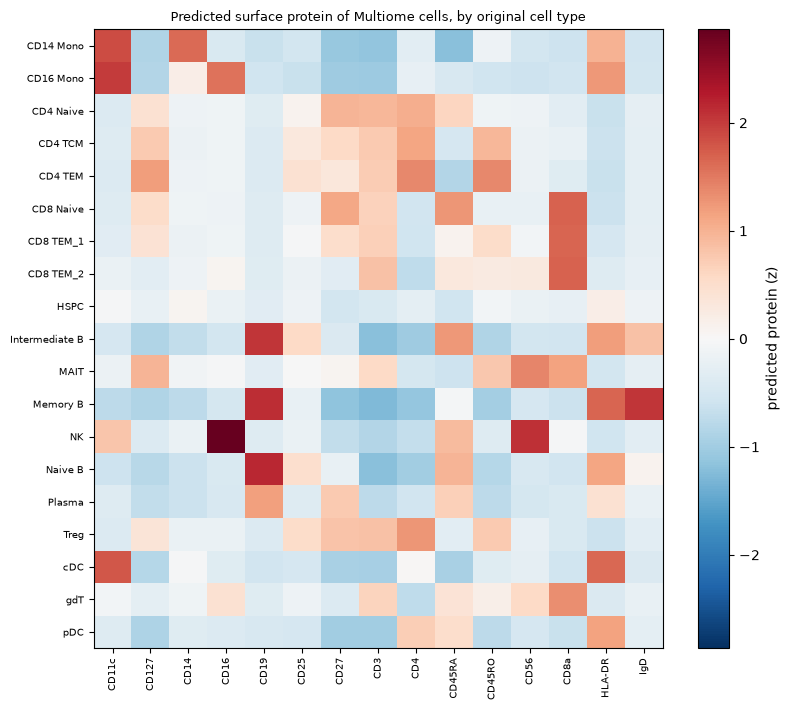

In [15]:
mt = data["Multiome"]["test"]
model.eval()
with torch.no_grad():
    mu = model.encode_fused({m: torch.as_tensor(dense(a.X), dtype=torch.float32, device=device)
                             for m, a in mt.items()}, use_mean=True)[0].cpu().numpy()
virtual = decode_from_latent(model, mu, device=device)["adt"]
virtual = pd.DataFrame(virtual, index=mt["rna"].obs_names, columns=adt_names)
by_type = virtual.groupby(mt["rna"].obs["cell_type"].astype(str).to_numpy()).mean()
show = [m for m in by_type.columns if norm_marker(m) in {"CD3", "CD4", "CD8", "CD8A", "CD19", "CD14", "CD16",
                                                         "CD56", "CD11C", "HLADR", "CD45RA", "CD45RO", "CD27",
                                                         "IGD", "CD127", "CD25"}] or list(by_type.columns[:16])
fig, ax = plt.subplots(figsize=(0.35 * len(show) + 3, 0.3 * len(by_type) + 1.5))
vals = by_type[show].to_numpy()
lim = np.abs(vals).max() or 1.0
im = ax.imshow(vals, cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto")
ax.set_xticks(range(len(show)), show, rotation=90, fontsize=7)
ax.set_yticks(range(len(by_type)), by_type.index, fontsize=7)
plt.colorbar(im, ax=ax, label="predicted protein (z)")
ax.set_title("Predicted surface protein of Multiome cells, by original cell type", fontsize=9)
plt.tight_layout()
plt.show()

## 7. Save the atlas

The stacked embedding with transferred labels goes to an `.h5ad` file, and the model, with every fitted
transform, to a reference bundle. The bundle's metadata records the antibody panel and the cohort
splits, so the atlas can be rebuilt and new cells mapped with the same transforms.

In [16]:
atlas.write_h5ad("pbmc_mosaic_atlas_test_cells.h5ad")
save_reference("pbmc_mosaic_reference", model,
               preprocessors={"per_cohort": preps, "atac": atac_prep, "genes": genes, "adt_panel": panel},
               metadata={"cohorts": list(data), "tea_holdout": TEA_HOLDOUT, "cite_label": CITE_LABEL,
                         "per_cohort_scaling": PER_COHORT_SCALING,
                         "splits": {"cite_obs": {k: cite["rna"].obs_names[v].tolist() for k, v in cite_idx.items()},
                                    "multiome_obs": {k: mult["rna"].obs_names[v].tolist() for k, v in mult_idx.items()},
                                    "tea_obs": {k: tea["rna"].obs_names[v].tolist() for k, v in tea_idx.items()}}})
print("saved")

saved


## What to try next

- **Where does the bridge break?** Rank antibodies by the gap between the full and bridge-only model
  (Section 4) and look for shared biology (e.g. activation markers with little transcript support).
- **Scaling choice.** Re-run with `PER_COHORT_SCALING = False` and compare cohort mixing and the
  held-out protein correlations.
- **Nuisance removal.** UniVI supports adversarial heads (`ClassHeadConfig(adversarial=True)`) that push
  a label, such as the cohort, out of the latent space. With the one-cohort-per-batch loader used here
  the adversary sees one class per batch, so this would need testing before being relied upon.
- **More modalities.** The AML mosaic (`aml_mosaic`) and the bridge cohorts (`pbmc_multiome_bridge`)
  follow the same pattern with RNA-only, ATAC-only or protein-only cohorts: add a loader per cohort.